   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
      

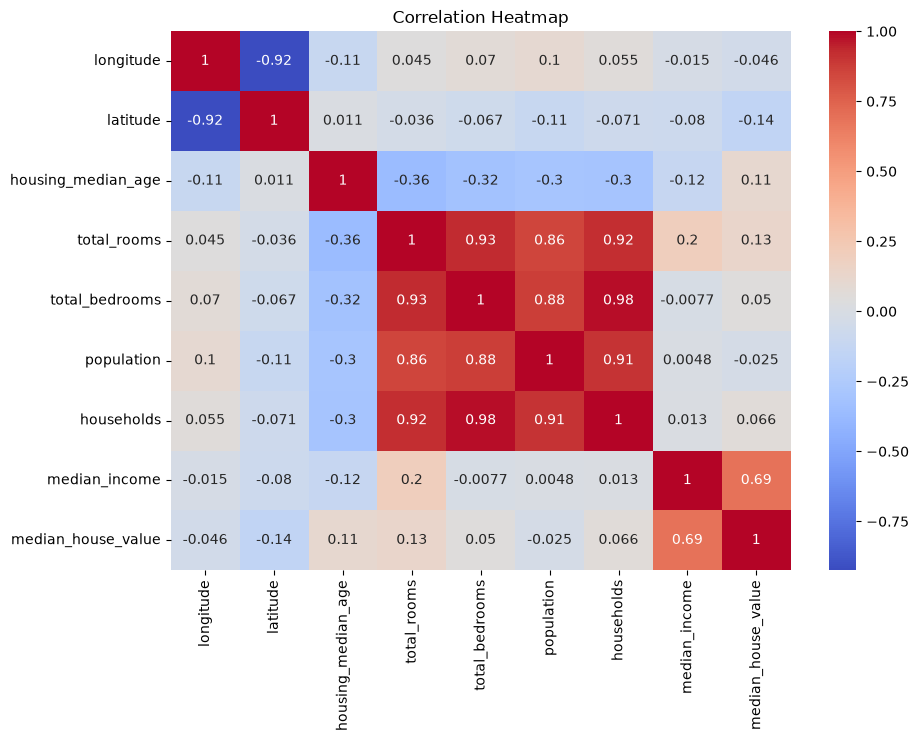

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

df = pd.read_csv("housing.csv")
# Display First Five Records

print(df.head())

# Display Numerical Columns

print(df.select_dtypes(include="number").columns)
# Calculate Correlation Matrix

correlation = df.corr(numeric_only=True)
print(correlation)

# Display Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Practical- 3B

In [16]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load Dataset

df = pd.read_csv("housing.csv")
# Select Independent and Dependent Variables

X = df[["median_income"]]
y = df["median_house_value"]

# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create Linear Regression Model

model = LinearRegression()


In [14]:
# Train the Model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict House Values

y_pred = model.predict(X_test)

# Display First 10 Predictions

print("Predicted Values:")

print(y_pred[:10])

# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Coefficient: 41793.849201896286
Intercept: 45085.5767032679
Predicted Values:
[115349.3959815  150878.34718803 190532.35131079 284881.96588407
 200767.66498033 242131.03753545 257561.32666079 199338.31533763
 245846.5107295  384167.43404809]
Mean Squared Error: 7090457293.46965


In [29]:
# Calculate R2 Score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.4589126439756298


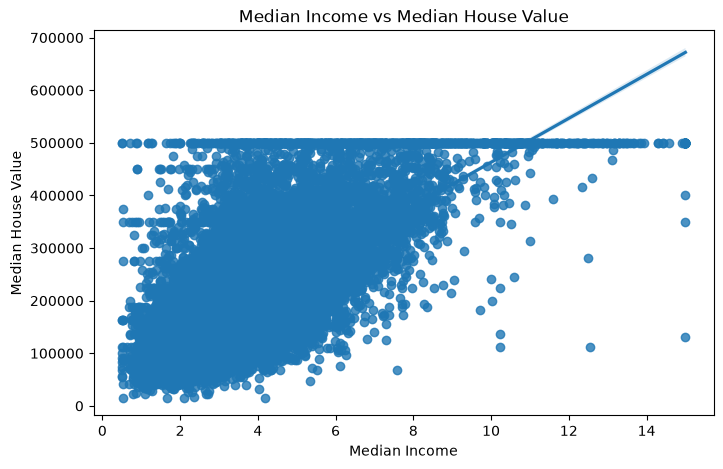

In [30]:
# Scatter Plot with Regression Line

plt.figure(figsize=(8, 5))

sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.xlabel("Median Income")

plt.ylabel("Median House Value")

plt.title("Median Income vs Median House Value")

plt.show()

Additional Questions on housing.csv

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("housing.csv")

numerical_df = df.select_dtypes(include="number")

correlation_matrix = numerical_df.corr()

print("Complete Correlation Matrix:")
print(correlation_matrix)

upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlations = upper.stack()

print("\nStrongest Positive Correlation:")
print(correlations.idxmax(), "=", correlations.max())

print("\nStrongest Negative Correlation:")
print(correlations.idxmin(), "=", correlations.min())

print("\nWeakest Correlation:")
print(correlations.abs().idxmin(), "=", correlations.loc[correlations.abs().idxmin()])

Complete Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.0710

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("housing.csv")

# Remove missing values
df = df.dropna()

# -------------------------------
# Multiple Regression
# -------------------------------

X = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "households"
    ]
]

Y = df["median_house_value"]

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Create model
multiple_model = LinearRegression()

# Train model
multiple_model.fit(X_train, Y_train)

# Prediction
Y_pred_multiple = multiple_model.predict(X_test)

# Evaluation
multiple_r2 = r2_score(Y_test, Y_pred_multiple)
multiple_mse = mean_squared_error(Y_test, Y_pred_multiple)

print("MULTIPLE REGRESSION MODEL")
print("--------------------------------")
print("R2 Score:", multiple_r2)
print("Mean Squared Error:", multiple_mse)


# -------------------------------
# Simple Regression
# -------------------------------

X_simple = df[["median_income"]]
Y_simple = df["median_house_value"]

X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(
    X_simple, Y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, Y_train_s)

Y_pred_simple = simple_model.predict(X_test_s)

simple_r2 = r2_score(Y_test_s, Y_pred_simple)
simple_mse = mean_squared_error(Y_test_s, Y_pred_simple)

print("\nSIMPLE REGRESSION MODEL")
print("--------------------------------")
print("R2 Score:", simple_r2)
print("Mean Squared Error:", simple_mse)


# -------------------------------
# Comparison
# -------------------------------

print("\nMODEL COMPARISON")
print("--------------------------------")

print("Multiple Regression R2:", multiple_r2)
print("Simple Regression R2:", simple_r2)

print("Multiple Regression MSE:", multiple_mse)
print("Simple Regression MSE:", simple_mse)

MULTIPLE REGRESSION MODEL
--------------------------------
R2 Score: 0.5689722351518441
Mean Squared Error: 5894382608.105016

SIMPLE REGRESSION MODEL
--------------------------------
R2 Score: 0.47196228574894983
Mean Squared Error: 7221011204.235033

MODEL COMPARISON
--------------------------------
Multiple Regression R2: 0.5689722351518441
Simple Regression R2: 0.47196228574894983
Multiple Regression MSE: 5894382608.105016
Simple Regression MSE: 7221011204.235033


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing.csv")

# Calculate correlation
correlation = df["total_rooms"].corr(df["median_house_value"])

print("Correlation between total_rooms and median_house_value:")
print(correlation)

Correlation between total_rooms and median_house_value:
0.1341531138065631


Task

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv("house_price_regression_dataset.csv")
print(df.head())
print(df.columns)

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  
Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')


In [3]:
correlation = df["Year_Built"].corr(df["House_Price"])
print("Correlation between Year_Built and House_Price:")
print(correlation)

Correlation between Year_Built and House_Price:
0.051967361931064486


In [4]:
correlation_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                      Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  \
Square_Footage              1.000000     -0.043564      -0.031584   -0.022392   
Num_Bedrooms               -0.043564      1.000000       0.022848   -0.015820   
Num_Bathrooms              -0.031584      0.022848       1.000000   -0.021063   
Year_Built                 -0.022392     -0.015820      -0.021063    1.000000   
Lot_Size                    0.089479     -0.009355       0.034923   -0.061050   
Garage_Size                 0.030593      0.113761       0.024846   -0.025485   
Neighborhood_Quality       -0.008357     -0.049024       0.017585   -0.009549   
House_Price                 0.991261      0.014633      -0.001862    0.051967   

                      Lot_Size  Garage_Size  Neighborhood_Quality  House_Price  
Square_Footage        0.089479     0.030593             -0.008357     0.991261  
Num_Bedrooms         -0.009355     0.113761             -0.049024     0.014633  
Num_Bat

In [5]:
X = df[["Year_Built"]]
Y = df["House_Price"]
model = LinearRegression()
model.fit(X, Y)
coefficient = model.coef_[0]
intercept = model.intercept_
print("Linear Regression: Year_Built -> House_Price")
print("Coefficient:", coefficient)
print("Intercept:", intercept)
print("\nRegression Equation:")
print(f"House_Price = {coefficient:.4f} * Year_Built + {intercept:.4f}")

Linear Regression: Year_Built -> House_Price
Coefficient: 638.6524884727304
Intercept: -649854.0823295026

Regression Equation:
House_Price = 638.6525 * Year_Built + -649854.0823


In [6]:
X = df[["Year_Built"]]
Y = df["House_Price"]
model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)
r2 = r2_score(Y, Y_pred)
print("R2 Score: Year_Built -> House_Price")
print(r2)

R2 Score: Year_Built -> House_Price
0.0027006067060743044


In [7]:
X = df[["Square_Footage"]]
Y = df["House_Price"]
model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)
r2 = r2_score(Y, Y_pred)
print("R2 Score: Square_Footage -> House_Price")
print(r2)

R2 Score: Square_Footage -> House_Price
0.9825992634147099


In [8]:
X = df[["Neighborhood_Quality"]]
Y = df["House_Price"]
model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)
r2 = r2_score(Y, Y_pred)
print("R2 Score: Neighborhood_Quality -> House_Price")
print(r2)

R2 Score: Neighborhood_Quality -> House_Price
6.037338916142776e-05


In [9]:
# Model 1: Year_Built -> House_Price
X1 = df[["Year_Built"]]
Y1 = df["House_Price"]
model1 = LinearRegression()
model1.fit(X1, Y1)
r2_1 = r2_score(Y1, model1.predict(X1))
# Model 2: Square_Footage -> House_Price
X2 = df[["Square_Footage"]]
Y2 = df["House_Price"]
model2 = LinearRegression()
model2.fit(X2, Y2)
r2_2 = r2_score(Y2, model2.predict(X2))
# Model 3: Neighborhood_Quality -> House_Price
X3 = df[["Neighborhood_Quality"]]
Y3 = df["House_Price"]
model3 = LinearRegression()
model3.fit(X3, Y3)
r2_3 = r2_score(Y3, model3.predict(X3))
# Compare R2 Scores
r2_scores = pd.DataFrame({
    "Regression Model": [
        "Year_Built -> House_Price",
        "Square_Footage -> House_Price",
        "Neighborhood_Quality -> House_Price"
    ],
    "R2 Score": [
        r2_1,
        r2_2,
        r2_3
    ]
})
print("Comparison of R2 Scores:")
print(r2_scores)
print("\nR2 Scores from highest to lowest:")
print(r2_scores.sort_values(by="R2 Score", ascending=False))

Comparison of R2 Scores:
                      Regression Model  R2 Score
0            Year_Built -> House_Price  0.002701
1        Square_Footage -> House_Price  0.982599
2  Neighborhood_Quality -> House_Price  0.000060

R2 Scores from highest to lowest:
                      Regression Model  R2 Score
1        Square_Footage -> House_Price  0.982599
0            Year_Built -> House_Price  0.002701
2  Neighborhood_Quality -> House_Price  0.000060
